In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [2]:
# Normalization and data augmentation
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]) # ImageNet standard
])

### <center>Prepare data</center>

In [4]:
train_dataset = datasets.ImageFolder("pneumonia_dataset/chest_xray/train", transform=transform)
val_dataset = datasets.ImageFolder("pneumonia_dataset/chest_xray/val", transform=transform)
test_dataset = datasets.ImageFolder("pneumonia_dataset/chest_xray/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

print(train_dataset.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}


#### <center> Transfer learning using ResNet <center>

In [5]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/home/jonathan/Desktop/medical-imaging/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jonathan/Desktop/medical-imaging/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

### <center> Training </center>

In [7]:
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.3f}")

Epoch 1, Loss: 0.110
Epoch 2, Loss: 0.058
Epoch 3, Loss: 0.044
Epoch 4, Loss: 0.037
Epoch 5, Loss: 0.027
Epoch 6, Loss: 0.030
Epoch 7, Loss: 0.023
Epoch 8, Loss: 0.026
Epoch 9, Loss: 0.016
Epoch 10, Loss: 0.014
Epoch 11, Loss: 0.015
Epoch 12, Loss: 0.010
Epoch 13, Loss: 0.015
Epoch 14, Loss: 0.009
Epoch 15, Loss: 0.012
Epoch 16, Loss: 0.021
Epoch 17, Loss: 0.011
Epoch 18, Loss: 0.013
Epoch 19, Loss: 0.010
Epoch 20, Loss: 0.007


In [8]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation accuracy:", correct/total)

Validation accuracy: 1.0


In [9]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.61      0.75       234
           1       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.82       624
weighted avg       0.88      0.85      0.84       624



#### <center> Display </center>

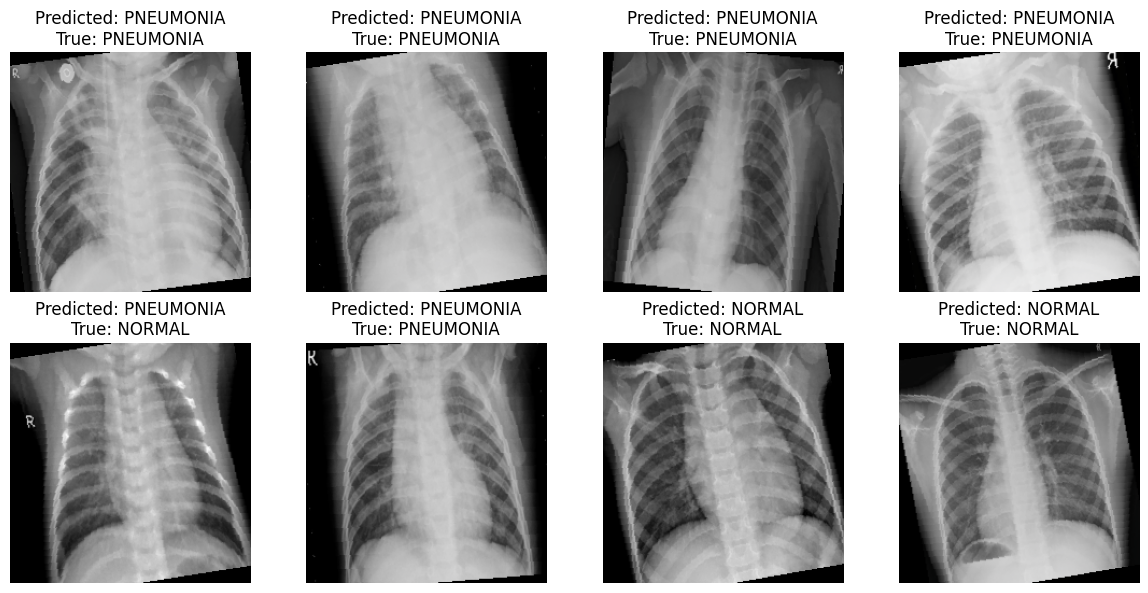

In [10]:
import numpy as np
import matplotlib.pyplot as plt

classes = ["NORMAL", "PNEUMONIA"]

# Get batch of test images
images, labels = next(iter(test_loader))

outputs = model(images.to(device))
_, preds = torch.max(outputs,1)

# Display predictions & actual labels
num_images = min(len(images), 8) # 8 images
cols = 4
rows = (num_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)

for idx in range(num_images):
    ax = axes[idx]
    img = images[idx].cpu().numpy()
    img = img * std + mean
    img = np.clip(img,0,1)
    ax.imshow(np.transpose(img, (1,2,0)))
    pred_label = classes[preds[idx].item()]
    true_label = classes[labels[idx].item()]
    ax.set_title(f"Predicted: {pred_label}\nTrue: {true_label}")
    ax.axis('off')

# Turn off unused subplots
for ax in axes[num_images:]:
    ax.axis('off')

plt.tight_layout()
plt.show()